# Memory experiment: Compute $ \langle \bar{0} | \bar{X} | \bar{0} \rangle$ with the five-qubit code

In [1]:
from typing import List, Dict, Sequence
import itertools
import functools
import numpy as np
import cirq
import qiskit
import qiskit_ibm_runtime
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler
import qsimcirq
import stim
import stimcirq
import matplotlib.pyplot as plt

from mitiq import PauliString

from encoded.diagonalize import get_stabilizer_matrix_from_paulis, get_measurement_circuit, get_paulis_from_stabilizer_matrix
from encoded.LST import bitGateMap, measure
from encoded.Laflamme_code import logical_H

import scipy
def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n-1)
    return m, h


## Set parameters

In [2]:
n = 5                                   
nshots = 100_000                        
depths = np.arange(0, 240 + 1, 20)      
k = 1                                   

In [3]:
computer = qiskit_ibm_runtime.fake_provider.FakeKyiv()
layout = {
    1 : [3],
    5 : [3,4,5,15,22],
}

## Helper functions

In [4]:
def compute_expectation(
    pauli: cirq.PauliString,
    counts: Dict[str, int],
) -> float:
    if pauli is cirq.PauliString():
        return 1.0

    expectation = 0.0

    indices = [q.x for q in pauli.qubits]
    for key, value in counts.items():
        key = list(map(int, list(key[::-1])))
        expectation += (-1) ** sum([key[i] for i in indices]) * value

    return expectation / sum(counts.values())


def parity_check_matrix_to_stabilizers(matrix: np.ndarray) -> List[stim.PauliString]:
    num_rows, num_cols = matrix.shape
    assert num_cols % 2 == 0
    num_qubits = num_cols // 2

    matrix = matrix.astype(np.bool8)  # indicate the data isn't bit packed
    return [
        stim.PauliString.from_numpy(
            xs=matrix[row, :num_qubits],
            zs=matrix[row, num_qubits:],
        )
        for row in range(num_rows)
    ]


def stabilizers_to_encoder(stabilizers) -> stim.Circuit:
    
    tableau = stim.Tableau.from_stabilizers(
        stabilizers,
        allow_underconstrained=True,
    )
    return tableau.to_circuit(method='graph_state')



# Prepares logical |0> state on [5,1,3] code
def encode_five(qreg: Sequence[cirq.Qid]) -> cirq.Circuit:
    a= stim.PauliString("+ZX_XZ")
    b=stim.PauliString("+XZZX_")
    c= stim.PauliString("+_XZZX")
    d=stim.PauliString("+X_XZZ")
    test_encoder1 = stabilizers_to_encoder([a,b,c ,d])
    circuit =stimcirq.stim_circuit_to_cirq_circuit(test_encoder1) 
    circuit.append(cirq.X.on_each(qreg))
    circuit.append( cirq.H.on_each(qreg))
    circuit.append( cirq.SWAP.on(qreg[0],qreg[1]))
    circuit.append( cirq.SWAP.on(qreg[1],qreg[4]))
    circuit.append( cirq.SWAP.on(qreg[4],qreg[3]))
    
    
    
    
    return circuit

def noisy_identity(qreg, depth):
    circuit = cirq.Circuit()

    if depth == 0:
        circuit.append(cirq.I.on_each(qreg))
    for _ in range(depth):
        circuit.append(cirq.X.on_each(qreg))
    return circuit

def strs_to_paulis(pauli_strs : List[str]) -> List[cirq.PauliString]:
    stab_list = []
    for stab_str in pauli_strs:
        stab_list.append(PauliString(stab_str)._pauli)
    return stab_list

def generate_stabilizer_elements(generators: List[cirq.PauliString]) -> List[cirq.PauliString]:
    elements = []
    for string in itertools.chain.from_iterable(itertools.combinations(generators, r) for r in range(len(generators) + 1)):
        elements.append(
            functools.reduce(lambda a, b: a * b, string, cirq.PauliString())
        )
    return elements

# For qiskit circuits
def get_active_qubits(circ):
    dag = qiskit.converters.circuit_to_dag(circ)
    active_qubits = [qubit for qubit in circ.qubits if qubit not in dag.idle_wires()]
    return active_qubits



def get_lst_ev(d_counts, n_counts, observables, stabilizers):
    numerator = 0
    for obs in observables:
        numerator += compute_expectation(obs, n_counts) / len(observables)
    denominator = 0
    for stab in stabilizers:
        denominator += compute_expectation(stab, d_counts) / len(stabilizers)
    return float(np.real_if_close(numerator / denominator))

In [5]:
encode_five(cirq.LineQubit.range(5))

0: ───RX───@───@───────────────H───X───H───×───────────
           │   │                           │
1: ───RX───┼───┼───@───@───────H───X───H───×───×───────
           │   │   │   │                       │
2: ───RX───@───┼───┼───┼───@───H───X───H───────┼───────
               │   │   │   │                   │
3: ───RX───────@───@───┼───┼───H───X───H───────┼───×───
                       │   │                   │   │
4: ───RX───────────────@───@───H───X───H───────×───×───

## Debug diagonalization

In [9]:
stabilizer_generators = [
    "XXXXX",
    "XZZXI",
    "IXZZX",
    "XIXZZ", 
    "ZXIXZ"
]
observable = PauliString("X"*5)._pauli

qreg = cirq.LineQubit.range(5)
stabilizer_generators = strs_to_paulis(stabilizer_generators)
stabilizer_matrix = get_stabilizer_matrix_from_paulis(stabilizer_generators, qreg)
measurement_circuit_x, transformed_matrix_x = get_measurement_circuit(stabilizer_matrix)
transformed_observable_x = observable.conjugated_by(measurement_circuit_x**-1)
print(transformed_observable_x,"\n",transformed_matrix_x)

Z(q(0)) 
 [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [12]:
transformed_generators

[Z(q(0)), Z(q(1)), Z(q(2)), Z(q(3)), Z(q(4))]

In [11]:
transformed_generators = get_paulis_from_stabilizer_matrix(transformed_matrix_x)
observable_elements = [transformed_observable_x * stab for stab in transformed_generators]
observable_elements

[I, Z(q(0))*Z(q(1)), Z(q(0))*Z(q(2)), Z(q(0))*Z(q(3)), Z(q(0))*Z(q(4))]

### Run unmitigated experiment

In [18]:
n_ave = 200
qreg = cirq.LineQubit.range(k)
unmit_evs = []
for depth in depths:
    
    circuit = noisy_identity(qreg, depth)
    circuit.append(cirq.H.on_each(qreg))
    circuit = qiskit.QuantumCircuit.from_qasm_str(circuit.to_qasm())
    circuit.measure_active()

    # Compile to device.
    compiled_raw = qiskit.transpile(
        circuit, 
        backend=computer,
        initial_layout=layout[1],  # Hardcode n = 1 (i.e., no encoding) to get layout.
        routing_method="sabre",
        # scheduling_method="asap",
        optimization_level=0,
    )
    ev = []
    for j in range(n_ave):
        job = computer.run(compiled_raw, shots=nshots)
        counts = job.result().get_counts()
        ev_tmp = compute_expectation(PauliString("Z")._pauli, counts)
        ev.append(ev_tmp)
    print(ev)
    mean, err = mean_confidence_interval(ev)
    unmit_evs.append(err)
    print(np.mean(ev), np.var(ev))

[0.00128, 0.0085, 0.00074, 0.0034, 0.00174, 0.00324, 0.00412, 0.00842, 0.00048, 0.00486, 0.00592, 0.00362, 0.00226, 0.00398, 0.00116, 0.00364, 0.0027, 0.00116, 0.00138, 0.00228, 0.00436, 0.00438, 0.00484, 0.00444, 0.00466, 0.00564, 0.00434, 0.00284, 0.00554, 0.0094, 0.00282, 0.00282, 0.00366, -0.00174, 0.00518, 0.00468, 0.00414, 0.00638, 0.00102, -0.00088, 0.00212, 0.00428, 0.00206, 0.00344, 0.00394, 0.00504, 0.0, 0.00226, 0.0105, 0.01136, 0.00624, 4e-05, 0.00432, 0.00392, -0.00162, 0.00106, 0.00266, 0.0061, -0.00332, 0.00572, 0.00936, 0.00286, 0.00766, 0.01194, 0.00186, 0.00028, 0.00664, 0.0029, 0.00076, 0.00552, 0.0014, 0.00274, 0.0088, 0.00486, 0.00136, 0.00504, 0.00384, -0.0009, 0.00532, 0.00304, 0.00216, 0.00296, 0.00134, 0.00258, -0.00182, -0.00024, 0.00398, 0.00674, 0.00374, -0.00032, -0.00022, 0.0029, 0.0031, 0.00102, 0.00364, 0.00348, 0.00124, 0.0028, 0.00426, -0.00262, 0.00766, 0.0044, 0.00178, 0.00488, 0.00508, -0.00394, 0.00492, 0.00294, 0.0009, 0.0003, -0.00016, 0.00482, -

# Run encoded experiment

In [8]:
generator_strs = [
    "XZZXI",
    "IXZZX",
    "XIXZZ", 
    "ZXIXZ"
]

observable = PauliString("X" * n)._pauli

qreg = cirq.LineQubit.range(n)

stabilizer_generators = strs_to_paulis(generator_strs)
stabilizer_matrix = get_stabilizer_matrix_from_paulis(stabilizer_generators, qreg)
measurement_circuit_denominator, transformed_matrix = get_measurement_circuit(stabilizer_matrix)
measurement_circuit_numerator = measurement_circuit_denominator.copy()

measurement_circuit_numerator.insert(0, cirq.SWAP.on(qreg[4],qreg[3]))
measurement_circuit_numerator.insert(0, cirq.SWAP.on(qreg[1],qreg[4]))
measurement_circuit_numerator.insert(0, cirq.SWAP.on(qreg[0],qreg[1]))
measurement_circuit_numerator.insert(0, cirq.H.on_each(qreg))
transformed_generators = get_paulis_from_stabilizer_matrix(transformed_matrix)
stabilizer_elements = generate_stabilizer_elements(transformed_generators)
# for stab in stabilizer_elements:
#     print(stab)

transformed_observable = observable.conjugated_by(measurement_circuit_numerator**-1)
observable_elements = [transformed_observable * stab for stab in stabilizer_elements]
# for obs in observable_elements:

In [9]:
from qiskit.circuit.library import Barrier
encoding = encode_five(qreg)
encoding = qiskit.QuantumCircuit.from_qasm_str(encoding.to_qasm())

# Convert to qiskit circuit
measurement_denominator = qiskit.QuantumCircuit.from_qasm_str(measurement_circuit_denominator.to_qasm())
measurement_numerator = qiskit.QuantumCircuit.from_qasm_str(measurement_circuit_numerator.to_qasm())

# Combine circuit segments
circ_denominator_full = encoding.compose(
        Barrier(n, label="encoding"), get_active_qubits(encoding)
    ).compose(Barrier(n, label="measurement"), get_active_qubits(encoding)
).compose(measurement_denominator)
circ_denominator_full.measure_active()

circ_numerator_full = encoding.compose(
        Barrier(n, label="encoding"), get_active_qubits(encoding)
    ).compose(Barrier(n, label="measurement"), get_active_qubits(encoding)
).compose(measurement_numerator)
circ_numerator_full.measure_active()

# Compile circuits
denominator_noiseless_compiled = qiskit.transpile(
    circ_denominator_full, 
    backend=computer,
    initial_layout=layout[n],
    routing_method="sabre",
    # scheduling_method="asap",
    optimization_level=3,
)

numerator_noiseless_compiled = qiskit.transpile(
    circ_numerator_full, 
    backend=computer,
    initial_layout=layout[n],
    routing_method="sabre",
    # scheduling_method="asap",
    optimization_level=3,
)

print(denominator_noiseless_compiled.draw(fold=-1, idle_wires=False))
print(numerator_noiseless_compiled.draw(fold=-1, idle_wires=False))

global phase: π/4
                ┌─────────┐ ┌────┐   ┌────────┐  ┌──────┐┌─────────┐ ┌────┐          ┌──────┐┌──────────┐                 ┌──────┐   ┌────────┐                                                                                                        ┌──────┐┌─────────┐ ┌────┐          ┌──────┐┌──────────┐                 ┌──────┐   ┌────────┐   ┌────┐                                                                                                                                                                                                                                               encoding  measurement ┌──────────┐┌────┐┌──────────┐                                                                                             ┌──────┐┌─────────┐   ┌────┐  ┌────────┐                                                                                                                                                                                                     ┌──────┐  ┌

### Add (noisy) identity to circuit and compute expectation values

In [10]:
mit_evs = []
for depth in depths:
    denominator_compiled = denominator_noiseless_compiled.copy_empty_like()
    for instruction in denominator_noiseless_compiled.data:
        if instruction.label == "measurement":
            for _ in range(depth):
                for q in get_active_qubits(denominator_compiled):
                    denominator_compiled.x(q)
        denominator_compiled.append(
            instruction, instruction.qubits
        )

    numerator_compiled = numerator_noiseless_compiled.copy_empty_like()
    for instruction in numerator_noiseless_compiled.data:
        if instruction.label == "measurement":
            for _ in range(depth):
                for q in get_active_qubits(numerator_compiled):
                    numerator_compiled.x(q)
        numerator_compiled.append(
            instruction, instruction.qubits
        )
        
    job = computer.run(
        [denominator_compiled, numerator_compiled],
        shots=nshots,
    )
    d_counts = job.result().get_counts()[0]
    n_counts = job.result().get_counts()[1]
    ev = get_lst_ev(d_counts, n_counts, observable_elements, stabilizer_elements)
    mit_evs.append(ev)
    print(ev)

0.003991672545207412
0.002216448958087313
-0.0032822757111597373
-0.003944372153545868


KeyboardInterrupt: 

### Make the measurement/diagonalization circuit noiseless and compute expectation values

In [17]:
from qiskit.circuit.library import UnitaryGate
from qiskit.transpiler import InstructionProperties

ideal_props = {
    (i,) : InstructionProperties(error=0.0, duration=0.0) for i in range(computer.num_qubits)
}

computer.target.add_instruction(UnitaryGate([[1, 0], [0, 1]]), ideal_props)
print(computer.target._gate_map['unitary'])

AttributeError: Instruction unitary is already in the target

In [11]:
from qiskit.circuit.library import UnitaryGate
denominator_noiseless_compiled_perfect_measurment = denominator_noiseless_compiled.copy_empty_like()

enc = True
mea = False
for instruction in denominator_noiseless_compiled.data:
    # print(instruction)
    if not mea and instruction.label != "encoding" and instruction.label != "measurement":
        op = instruction
    elif instruction.label == "encoding":
        enc = False
        op = instruction
    elif instruction.label == "measurement":
        mea = True
        op = instruction
    elif instruction.matrix is None:
        op = instruction
    else:
        op = UnitaryGate(instruction.matrix, label="ideal_" + instruction.operation.name)
    denominator_noiseless_compiled_perfect_measurment.append(
        op, instruction.qubits
    )

numerator_noiseless_compiled_perfect_measurment = denominator_noiseless_compiled.copy_empty_like()

enc = True
mea = False
for instruction in numerator_noiseless_compiled.data:
    # print(instruction)
    if not mea and instruction.label != "encoding" and instruction.label != "measurement":
        op = instruction
    elif instruction.label == "encoding":
        enc = False
        op = instruction
    elif instruction.label == "measurement":
        mea = True
        op = instruction
    elif instruction.matrix is None:
        op = instruction
    else:
        op = UnitaryGate(instruction.matrix, label="ideal_" + instruction.operation.name)
    numerator_noiseless_compiled_perfect_measurment.append(
        op, instruction.qubits
    )
# print(noiseless_compiled_perfect_measurment.count_ops())
print(denominator_noiseless_compiled_perfect_measurment.draw(fold=-1, idle_wires=False))
print(numerator_noiseless_compiled_perfect_measurment.draw(fold=-1, idle_wires=False))

global phase: π/4
                ┌─────────┐ ┌────┐   ┌────────┐  ┌──────┐┌─────────┐ ┌────┐          ┌──────┐┌──────────┐                 ┌──────┐   ┌────────┐                                                                                                        ┌──────┐┌─────────┐ ┌────┐          ┌──────┐┌──────────┐                 ┌──────┐   ┌────────┐   ┌────┐                                                                                                                                                                                                                                               encoding  measurement ┌──────────┐┌──────────┐┌──────────┐                                                                                                                              ┌────────────┐┌──────────┐┌──────────┐ ┌──────────┐                                                                                                                                                              

In [15]:
mit_evs_im_means = []
mit_evs_im_var = []
n_ave = 200
for depth in depths:
    ev = []
    for _ in range(n_ave):
        denominator_compiled = denominator_noiseless_compiled_perfect_measurment.copy_empty_like()
        for instruction in denominator_noiseless_compiled_perfect_measurment.data:
            if instruction.label == "measurement":
                for _ in range(depth):
                    for q in get_active_qubits(denominator_compiled):
                        denominator_compiled.x(q)
            denominator_compiled.append(
                instruction, instruction.qubits
            )

        numerator_compiled = numerator_noiseless_compiled_perfect_measurment.copy_empty_like()
        for instruction in numerator_noiseless_compiled_perfect_measurment.data:
            if instruction.label == "measurement":
                for _ in range(depth):
                    for q in get_active_qubits(numerator_compiled):
                        numerator_compiled.x(q)
            numerator_compiled.append(
                instruction, instruction.qubits
            )

        job = computer.run(
            [denominator_compiled, numerator_compiled],
            shots=nshots,
        )
        d_counts = job.result().get_counts()[0]
        n_counts = job.result().get_counts()[1]
        ev_tmp = get_lst_ev(d_counts, n_counts, observable_elements, stabilizer_elements)
        ev.append(ev_tmp)
    mean, err = mean_confidence_interval(ev)
    mit_evs_im_means.append(np.mean(ev))
    mit_evs_im_var.append(err)
    print(mean,err)

-0.0013589078833742092 0.00046292369386039873
-0.0015555965901218006 0.0005124464641878217
-0.0014254317929831132 0.0005537913834327891
-0.0019654485768188863 0.0005718650618908666
-0.0019526785326359603 0.0005822878072044147
-0.002331970866252421 0.0005289279999809055
-0.0016517216329569246 0.0005378226748065018
-0.0016007154156005166 0.0006087259003486676
-0.0014238400396238502 0.0006117047813717733
-0.0018739866530793645 0.0005874645300373502
-0.0009398014869235913 0.0006404460931319381
-0.0015549990936723765 0.0006512906711264154
-0.001498644487848395 0.0007304079809194786


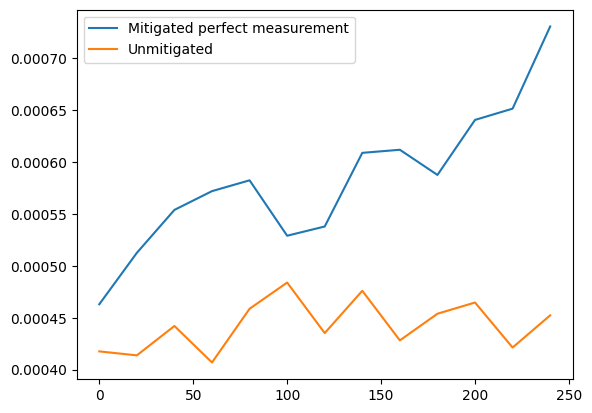

In [19]:
plt.figure()
plt.plot(depths, np.array(mit_evs_im_var), label="Mitigated perfect measurement")
plt.plot(depths, np.array(unmit_evs), label="Unmitigated")

plt.legend()
plt.show()

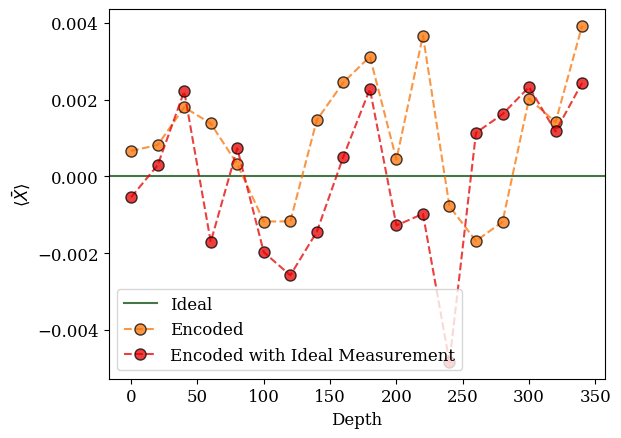

In [20]:
plt.rcParams.update({"font.family": "serif", "font.size": 12})
colors = ["xkcd:blue", "xkcd:orange", "xkcd:red"]
alpha: float = 0.75
stop: int = 20

# plt.title("Measuring $\\langle\\overline{Z}\\rangle$ on $|0\\rangle$ with Steane [[7,1,3]] Code")
plt.ylabel(r"$\langle \bar{X} \rangle$")
plt.xlabel("Depth")
# plt.plot(depths[:stop], [1.0] * len(depths[:stop]), "--", label="Ideal")
plt.axhline(0.0, label="Ideal", alpha=0.75, color="xkcd:darkgreen")
# plt.plot(depths[:stop], unmit_evs[:stop], "--o", color=colors[0], alpha=alpha, mec="black", ms=8, label="Raw")
plt.plot(depths[:stop], (mit_evs[:stop]), "--o", alpha=alpha, color=colors[1], mec="black", ms=8, label="Encoded")
plt.plot(depths[:stop], (mit_evs_im[:stop]), "--o", alpha=alpha, color=colors[2], mec="black", ms=8, label="Encoded with Ideal Measurement")
plt.legend()
plt.savefig(f"five_qubit_code_[[5,1,3]]_logical_zero_logical_z_{computer.name}.pdf")
plt.show()